<div style="background: linear-gradient(135deg, #0d1117 0%, #161b22 100%);
             border: 1px solid #30363d; border-radius: 14px;
             padding: 48px 44px; text-align: center; margin-bottom: 4px;">

  <h1 style="color: #58a6ff; font-size: 2.6em; font-weight: 800;
             letter-spacing: 0.5px; margin: 0 0 10px 0;">
    BaseLine Health
  </h1>

  <p style="color: #c9d1d9; font-size: 1.15em; margin: 0 0 6px 0;">
    AI-Powered Personalized Health Monitoring System
  </p>

  <p style="color: #484f58; font-size: 0.9em; margin: 0;">
    Unsupervised Learning &nbsp;·&nbsp; Anomaly Detection &nbsp;·&nbsp;
    Personalized Baseline Discovery
  </p>

</div>

## Project Overview

Most health apps compare your readings against a **population average**.
This system is different — it learns **your personal baseline** from your own
history, then flags moments that deviate from *your* normal.

> **Core idea:** What is abnormal for you might be normal for someone else.

---

### How it works

```
Your Data  →  Learn Your Normal  →  Detect Deviations  →  Health Insights
```

### Workflow

| Step | Section | What happens |
|------|---------|-------------|
| 1 | Load Dataset | Read wearable sensor data |
| 2 | Select One Person | Filter to a single user |
| 3 | Clean & Explore | Validate and understand the data |
| 4 | Engineer Features | Build meaningful health signals |
| 5 | Scale Features | Normalize for ML |
| 6 | Learn Baseline | PCA — visualize the person's behavioral space |
| 7 | Isolation Forest | Detect anomalies by isolation |
| 8 | DBSCAN | Detect anomalies by density |
| 9 | K-Means | Discover behavioral clusters |
| 10 | Visualize | Charts and anomaly highlights |
| 11 | Health Insights | Severity scores and personalized findings |
| 12 | Compare & Conclude | Best model selection and summary |

---
## 0 · Imports & Configuration

In [90]:
# ─── Standard libraries ────────────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
from pathlib import Path

# ─── Machine Learning ───────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score

# ─── Visualization ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')

# ─── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ───────────────────────────────────────────────────────────────────────────
#  PROJECT CONFIGURATION
#  Change USER_ID here to switch to a different person.
# ───────────────────────────────────────────────────────────────────────────
USER_ID       = 'adult_001'      # which person to analyse
DATA_FOLDER   = Path('.')        # folder containing the CSV files
CONTAMINATION = 0.05             # expected fraction of anomalies (5%)

# ─── Visual theme ───────────────────────────────────────────────────────────
PRIMARY   = '#58a6ff'    # blue  — main signal / normal
ANOMALY   = '#e94560'    # red   — anomaly markers
BASELINE  = '#3fb950'    # green — baseline / rolling average
SECONDARY = '#d29922'    # amber — secondary markers

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'axes.titlesize':   12,
    'axes.labelsize':   10,
})

print(f'✓ Setup complete')
print(f'  Analysing user : {USER_ID}')
print(f'  Data folder    : {DATA_FOLDER.resolve()}')

✓ Setup complete
  Analysing user : adult_001
  Data folder    : /Users/praneethpalleti/Downloads/projects/BaseLine_Health


---
## 1 · Load Dataset

We load all wearable sensor CSV files from the data folder.
Each file contains one person's readings sampled every **5 minutes** over 7 days.

In [91]:
# Load all CSV files and combine them into one DataFrame
csv_files = sorted(DATA_FOLDER.glob('*.csv'))
print(f'Files found: {[f.name for f in csv_files]}')

all_data = pd.concat(
    [pd.read_csv(f) for f in csv_files],
    ignore_index=True
)

# Convert timestamp string → proper datetime object
all_data['timestamp'] = pd.to_datetime(all_data['timestamp'])
all_data = all_data.sort_values(['user_id', 'timestamp']).reset_index(drop=True)

print(f'\nAll users    : {all_data["user_id"].unique().tolist()}')
print(f'Total rows   : {len(all_data):,}')
print(f'Date range   : {all_data["timestamp"].min().date()} → {all_data["timestamp"].max().date()}')
print(f'Columns      : {all_data.columns.tolist()}')

all_data.head()

Files found: ['adult_001.csv', 'child_001.csv', 'elderly_001.csv']

All users    : ['adult_001', 'child_001', 'elderly_001']
Total rows   : 6,048
Date range   : 2026-05-10 → 2026-05-16
Columns      : ['user_id', 'timestamp', 'heart_rate', 'steps', 'movement_level', 'sleep_state']


,user_id,timestamp,heart_rate,steps,movement_level,sleep_state
0,adult_001,2026-05-10 00:00:00,63,3,low,awake
1,adult_001,2026-05-10 00:05:00,64,4,low,awake
2,adult_001,2026-05-10 00:10:00,62,5,low,awake
3,adult_001,2026-05-10 00:15:00,63,4,low,awake
4,adult_001,2026-05-10 00:20:00,65,3,low,awake


---
## 2 · Select Single User

We filter the data to **one person only**.
All models will be trained exclusively on this person's data —
so the system learns *their* normal, not a population average.

> To analyse a different person, change `USER_ID` in the Config cell above.

In [92]:
# Filter to one person
user_df = all_data[all_data['user_id'] == USER_ID].copy()
user_df = user_df.reset_index(drop=True)

label = USER_ID.replace('_001', '').capitalize()

print(f'{"─"*45}')
print(f'  Analysing: {label.upper()} ({USER_ID})')
print(f'{"─"*45}')
print(f'  Rows       : {len(user_df):,}  (every 5 minutes for 7 days)')
print(f'  Start      : {user_df["timestamp"].min()}')
print(f'  End        : {user_df["timestamp"].max()}')
print()

# Quick look at the raw data
user_df.head(10)

─────────────────────────────────────────────
  Analysing: ADULT (adult_001)
─────────────────────────────────────────────
  Rows       : 2,016  (every 5 minutes for 7 days)
  Start      : 2026-05-10 00:00:00
  End        : 2026-05-16 23:55:00



,user_id,timestamp,heart_rate,steps,movement_level,sleep_state
0,adult_001,2026-05-10 00:00:00,63,3,low,awake
1,adult_001,2026-05-10 00:05:00,64,4,low,awake
2,adult_001,2026-05-10 00:10:00,62,5,low,awake
3,adult_001,2026-05-10 00:15:00,63,4,low,awake
4,adult_001,2026-05-10 00:20:00,65,3,low,awake
5,adult_001,2026-05-10 00:25:00,64,4,low,awake
6,adult_001,2026-05-10 00:30:00,63,18,medium,awake
7,adult_001,2026-05-10 00:35:00,64,19,medium,awake
8,adult_001,2026-05-10 00:40:00,65,25,medium,awake
9,adult_001,2026-05-10 00:45:00,62,24,medium,awake


---
## 3 · Data Cleaning & Exploration

Before building any model, we validate the data quality and understand
what the person's typical readings look like.

In [93]:
# ── Check data quality ──────────────────────────────────────────────────────
print('DATA QUALITY CHECK')
print('─' * 35)

# Missing values
missing = user_df.isnull().sum()
print(f'Missing values:')
if missing.any():
    print(missing[missing > 0])
else:
    print('  None ✓')

# Duplicates
n_dupes = user_df.duplicated().sum()
print(f'\nDuplicate rows : {n_dupes}  {"✓" if n_dupes == 0 else "⚠ fix needed"}')

# Timestamp gaps
time_gaps = user_df['timestamp'].diff().dropna()
expected  = pd.Timedelta('5 min')
unexpected_gaps = time_gaps[time_gaps != expected]
print(f'Timestamp gaps : {len(unexpected_gaps)} unexpected  '
      f'{"✓" if len(unexpected_gaps) == 0 else "⚠ check these"}')

DATA QUALITY CHECK
───────────────────────────────────
Missing values:
  None ✓

Duplicate rows : 0  ✓
Timestamp gaps : 0 unexpected  ✓


In [94]:
# ── Summary statistics ──────────────────────────────────────────────────────
print(f'HEALTH SUMMARY — {USER_ID.replace("_001","").upper()}')
print('─' * 45)

hr_stats    = user_df['heart_rate'].describe()
step_stats  = user_df['steps'].describe()

print(f'\nHeart Rate (bpm):')
print(f'  Average : {hr_stats["mean"]:.1f}')
print(f'  Min - Max : {hr_stats["min"]:.0f} - {hr_stats["max"]:.0f}')
print(f'  Std Dev : {hr_stats["std"]:.1f}')

print(f'\nSteps (per 5 min):')
print(f'  Average : {step_stats["mean"]:.1f}')
print(f'  Max     : {step_stats["max"]:.0f}')

sleep_pct = (user_df['sleep_state'] == 'asleep').mean() * 100
awake_pct = 100 - sleep_pct
print(f'\nSleep \ Awake split:')
print(f'  Asleep  : {sleep_pct:.1f}%  ({sleep_pct/100 * 7 * 24:.1f} hours over 7 days)')
print(f'  Awake   : {awake_pct:.1f}%')

move_counts = user_df['movement_level'].value_counts(normalize=True) * 100
print(f'\nMovement levels:')
for level, pct in move_counts.items():
    print(f'  {level:8s} : {pct:.1f}%')

HEALTH SUMMARY — ADULT
─────────────────────────────────────────────

Heart Rate (bpm):
  Average : 70.9
  Min - Max : 49 - 102
  Std Dev : 11.2

Steps (per 5 min):
  Average : 31.9
  Max     : 156

Sleep \ Awake split:
  Asleep  : 29.7%  (49.8 hours over 7 days)
  Awake   : 70.3%

Movement levels:
  medium   : 52.3%
  low      : 39.0%
  high     : 8.7%


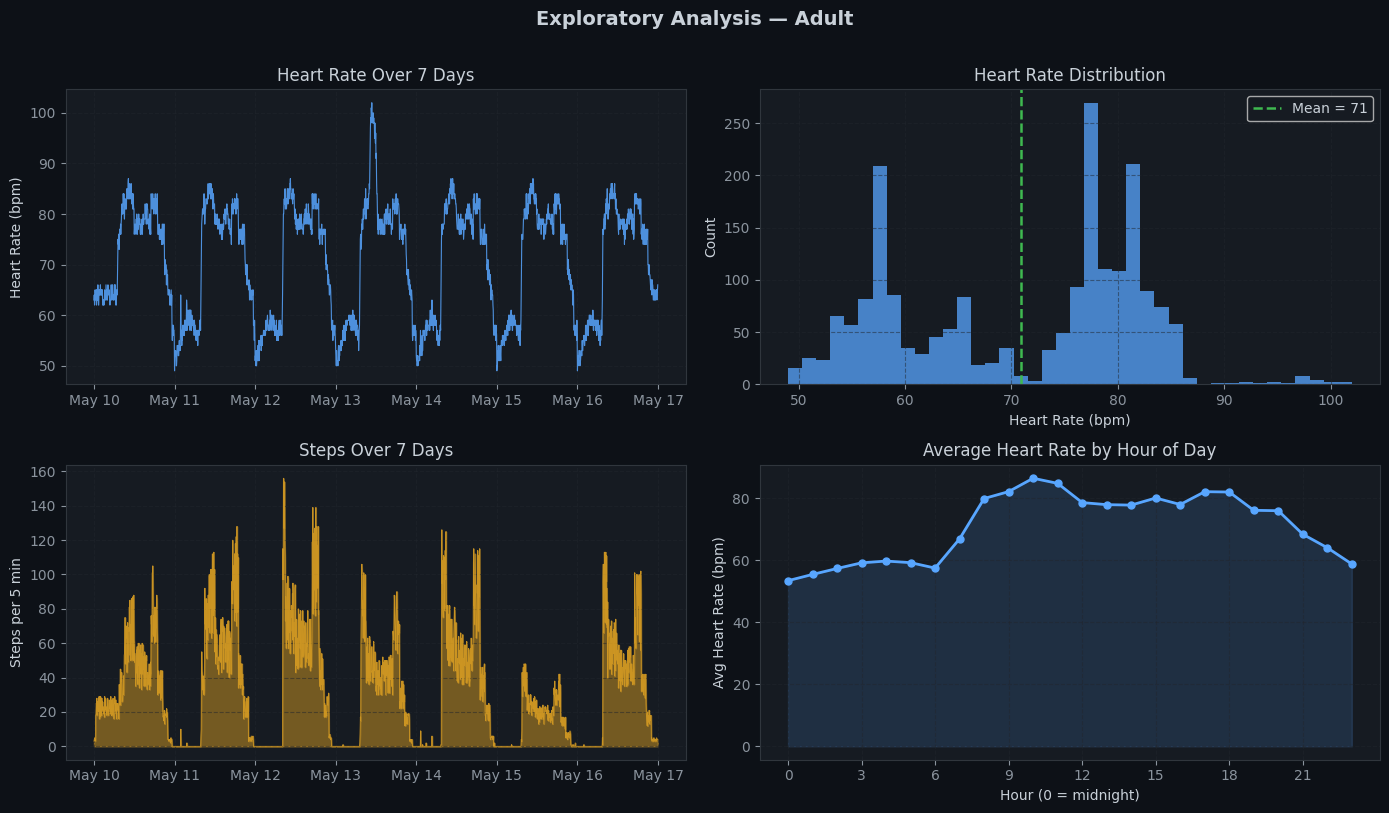

In [95]:
# ── Exploratory plots — heart rate and steps ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f'Exploratory Analysis — {USER_ID.replace("_001","").capitalize()}',
             fontsize=14, fontweight='bold', y=1.01)

# 1. Heart rate over time
ax = axes[0, 0]
ax.plot(user_df['timestamp'], user_df['heart_rate'],
        color=PRIMARY, linewidth=0.8, alpha=0.85)
ax.set_title('Heart Rate Over 7 Days')
ax.set_ylabel('Heart Rate (bpm)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.grid(True)

# 2. Heart rate distribution
ax = axes[0, 1]
ax.hist(user_df['heart_rate'], bins=40, color=PRIMARY,
        alpha=0.75, edgecolor='none')
ax.axvline(user_df['heart_rate'].mean(), color=BASELINE,
           linestyle='--', linewidth=1.8, label=f'Mean = {user_df["heart_rate"].mean():.0f}')
ax.set_title('Heart Rate Distribution')
ax.set_xlabel('Heart Rate (bpm)')
ax.set_ylabel('Count')
ax.legend()
ax.grid(True)

# 3. Steps over time
ax = axes[1, 0]
ax.fill_between(user_df['timestamp'], user_df['steps'],
                color=SECONDARY, alpha=0.5)
ax.plot(user_df['timestamp'], user_df['steps'],
        color=SECONDARY, linewidth=0.6, alpha=0.9)
ax.set_title('Steps Over 7 Days')
ax.set_ylabel('Steps per 5 min')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.grid(True)

# 4. Average heart rate by hour of day
ax = axes[1, 1]
hourly_hr = user_df.copy()
hourly_hr['hour'] = hourly_hr['timestamp'].dt.hour
hourly_avg = hourly_hr.groupby('hour')['heart_rate'].mean()
ax.plot(hourly_avg.index, hourly_avg.values,
        color=PRIMARY, marker='o', linewidth=2, markersize=5)
ax.fill_between(hourly_avg.index, hourly_avg.values,
                alpha=0.15, color=PRIMARY)
ax.set_title('Average Heart Rate by Hour of Day')
ax.set_xlabel('Hour (0 = midnight)')
ax.set_ylabel('Avg Heart Rate (bpm)')
ax.set_xticks(range(0, 24, 3))
ax.grid(True)

plt.tight_layout()
plt.savefig('/tmp/eda_plots.png', dpi=100, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

---
## 4 · Feature Engineering

Raw sensor readings are not always the best input for ML models.
We build **behavioral features** that capture *how* a person is doing,
not just what the raw numbers say.

| Feature | Description |
|---|---|
| `heart_rate` | Raw heart rate (bpm) |
| `steps` | Steps taken in this 5-min window |
| `activity_level` | Movement level encoded as 0 (low) / 1 (medium) / 2 (high) |
| `is_asleep` | Sleep state encoded as 0 (awake) / 1 (asleep) |
| `hour` | Hour of day — captures daily rhythm |
| `hr_rolling_avg` | 1-hour rolling average of heart rate (short-term trend) |
| `hr_variability` | 1-hour rolling std of heart rate (how much HR is fluctuating) |
| `trend_delta` | 1h average minus 4h average — is HR rising above normal? |
| `step_rate` | Steps per minute equivalent — activity intensity |

In [96]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build behavioral features from raw sensor data.
    All rolling windows use 5-minute intervals:
      12 rows = 1 hour
      48 rows = 4 hours
    """
    df = df.copy()

    # ── Encode text columns to numbers ──────────────────────────────────────
    df['activity_level'] = df['movement_level'].map({
        'low': 0, 'medium': 1, 'high': 2
    })
    df['is_asleep'] = (df['sleep_state'] == 'asleep').astype(int)

    # ── Time-of-day feature ──────────────────────────────────────────────────
    df['hour'] = df['timestamp'].dt.hour

    # ── Rolling heart rate features ──────────────────────────────────────────
    # 1-hour rolling average: captures the short-term trend
    df['hr_rolling_avg'] = (
        df['heart_rate']
        .rolling(window=12, min_periods=1)
        .mean()
    )

    # 1-hour rolling standard deviation: how much is HR varying?
    df['hr_variability'] = (
        df['heart_rate']
        .rolling(window=12, min_periods=2)
        .std()
        .fillna(0)
    )

    # 4-hour rolling average: captures the medium-term trend
    hr_4h = (
        df['heart_rate']
        .rolling(window=48, min_periods=1)
        .mean()
    )

    # Trend delta: positive = HR rising above 4-hour average
    df['trend_delta'] = df['hr_rolling_avg'] - hr_4h

    # ── Activity intensity ───────────────────────────────────────────────────
    # Steps per 5-min window converted to steps/minute
    df['step_rate'] = df['steps'] / 5.0

    return df


# Apply feature engineering
user_df = build_features(user_df)

FEATURE_COLS = [
    'heart_rate',
    'steps',
    'activity_level',
    'is_asleep',
    'hour',
    'hr_rolling_avg',
    'hr_variability',
    'trend_delta',
    'step_rate',
]

print('Features built:')
for col in FEATURE_COLS:
    print(f'  {col:20s}  mean={user_df[col].mean():.2f}  std={user_df[col].std():.2f}')

Features built:
  heart_rate            mean=70.86  std=11.21
  steps                 mean=31.90  std=31.85
  activity_level        mean=0.70  std=0.62
  is_asleep             mean=0.30  std=0.46
  hour                  mean=11.50  std=6.92
  hr_rolling_avg        mean=70.86  std=10.97
  hr_variability        mean=1.96  std=1.44
  trend_delta           mean=0.02  std=5.71
  step_rate             mean=6.38  std=6.37


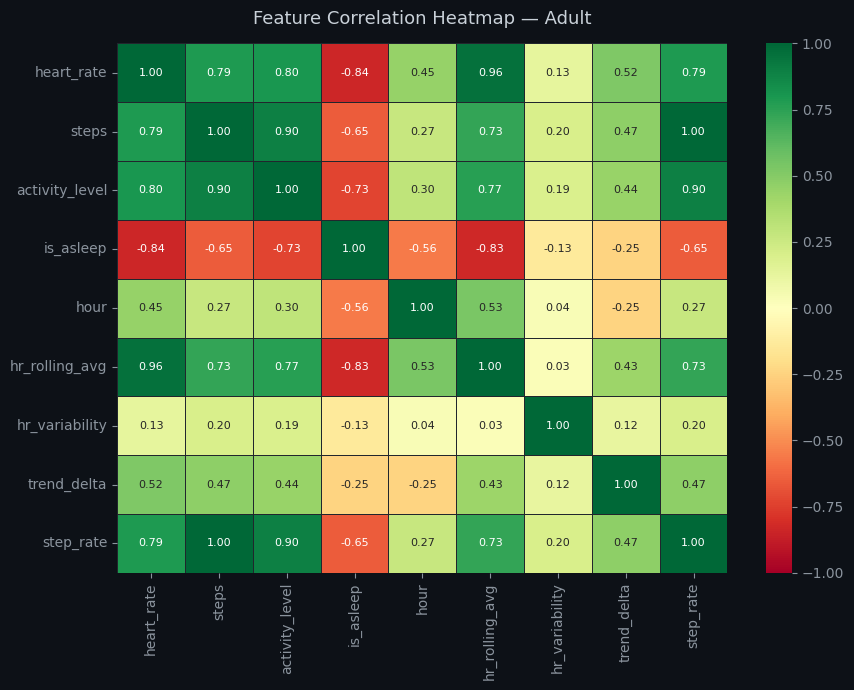

Strong correlations to remember:
     feature_1      feature_2  correlation
         steps      step_rate     1.000000
    heart_rate hr_rolling_avg     0.960898
activity_level      step_rate     0.896416
         steps activity_level     0.896416
    heart_rate      is_asleep    -0.839756


In [97]:
# ── Correlation heatmap — which features are related? ───────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

corr = user_df[FEATURE_COLS].corr()

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True   # hide upper triangle

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5,
    linecolor='#21262d',
    annot_kws={'size': 8},
)
ax.set_title(f'Feature Correlation Heatmap — {USER_ID.replace("_001","").capitalize()}',
             fontsize=13, pad=14)
plt.tight_layout()
plt.show()

print('Strong correlations to remember:')
corr_pairs = (
    corr.where(mask)
    .stack()
    .reset_index()
    .rename(columns={0: 'correlation',
                     'level_0': 'feature_1',
                     'level_1': 'feature_2'})
    .sort_values('correlation', key=abs, ascending=False)
)
print(corr_pairs.head(5).to_string(index=False))

---
## 5 · Feature Scaling

ML models like K-Means and DBSCAN use **distances** between points.
If one feature has a range of 0–120 (heart rate) and another has 0–2 (activity level),
the larger-scale feature will dominate the distance calculation.

**StandardScaler** fixes this by transforming every feature to:
- Mean ≈ 0
- Standard deviation ≈ 1

This puts all features on equal footing.

In [98]:
# Select only the feature columns and handle any missing values
X_raw = user_df[FEATURE_COLS].fillna(0).values

# Fit the scaler on this user's data only
scaler = StandardScaler()
X      = scaler.fit_transform(X_raw)

print('Scaling complete.')
print(f'  Input shape   : {X_raw.shape}')
print(f'  Output shape  : {X.shape}')
print()

# Verify scaling worked
print('Before scaling (first 3 features):')
for i, col in enumerate(FEATURE_COLS[:3]):
    print(f'  {col:20s}  mean={X_raw[:,i].mean():.2f}  std={X_raw[:,i].std():.2f}')

print()
print('After scaling (first 3 features):')
for i, col in enumerate(FEATURE_COLS[:3]):
    print(f'  {col:20s}  mean={X[:,i].mean():.4f}  std={X[:,i].std():.4f}')

Scaling complete.
  Input shape   : (2016, 9)
  Output shape  : (2016, 9)

Before scaling (first 3 features):
  heart_rate            mean=70.86  std=11.21
  steps                 mean=31.90  std=31.84
  activity_level        mean=0.70  std=0.62

After scaling (first 3 features):
  heart_rate            mean=-0.0000  std=1.0000
  steps                 mean=0.0000  std=1.0000
  activity_level        mean=-0.0000  std=1.0000


---
## 6 · Personalized Baseline — PCA Visualization

**PCA (Principal Component Analysis)** compresses our 9 features into 2 dimensions
so we can see the "shape" of this person's behavioral space.

- A **tight, well-defined cluster** = consistent, predictable behavior
- Points that **fall far from the main cluster** = potential anomalies

This gives us a visual picture of what "normal" looks like for this person.

In [99]:
# Reduce 9 features → 2 principal components for visualization
pca    = PCA(n_components=2, random_state=SEED)
X_pca  = pca.fit_transform(X)

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100
total_var = var1 + var2

print(f'PCA — Explained Variance')
print(f'  PC1  :  {var1:.1f}%')
print(f'  PC2  :  {var2:.1f}%')
print(f'  Total:  {total_var:.1f}%  (of 9 original features captured in 2D)')

PCA — Explained Variance
  PC1  :  61.0%
  PC2  :  15.5%
  Total:  76.5%  (of 9 original features captured in 2D)


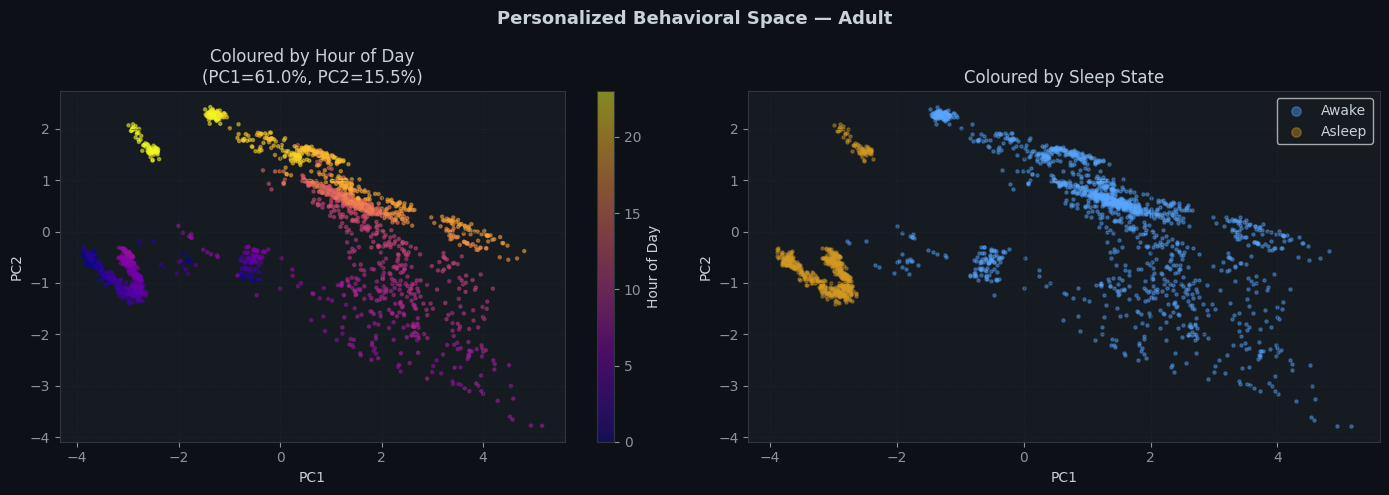


Interpretation:
  Distinct regions = the person naturally has different behavioral modes.
  Points far from clusters = potential anomalies to investigate.


In [100]:
# ── Plot the behavioral space ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Personalized Behavioral Space — {USER_ID.replace("_001","").capitalize()}',
             fontsize=13, fontweight='bold')

# Left: colour by time of day (hour)
ax = axes[0]
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=user_df['hour'].values,
    cmap='plasma',
    s=5, alpha=0.5
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Hour of Day', color='#c9d1d9')
cbar.ax.yaxis.set_tick_params(color='#8b949e')
ax.set_title(f'Coloured by Hour of Day\n(PC1={var1:.1f}%, PC2={var2:.1f}%)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.grid(True)

# Right: colour by sleep state
ax = axes[1]
asleep = user_df['is_asleep'].values == 1
awake  = user_df['is_asleep'].values == 0
ax.scatter(X_pca[awake, 0],  X_pca[awake, 1],
           c=PRIMARY, s=5, alpha=0.4, label='Awake')
ax.scatter(X_pca[asleep, 0], X_pca[asleep, 1],
           c=SECONDARY, s=5, alpha=0.4, label='Asleep')
ax.set_title('Coloured by Sleep State')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(fontsize=10, markerscale=3)
ax.grid(True)

plt.tight_layout()
plt.show()

print(f'\nInterpretation:')
print(f'  Distinct regions = the person naturally has different behavioral modes.')
print(f'  Points far from clusters = potential anomalies to investigate.')

---
## 7 · Model 1 — Isolation Forest

### How it works
Isolation Forest builds many random decision trees.
It measures how many splits it takes to **isolate** each data point.

- **Normal readings** → need many splits to isolate (they live in dense regions)
- **Anomalies** → isolated in very few splits (they live alone in sparse regions)

### Why it's great for health monitoring
It doesn't assume any shape for "normal" — it just learns what the data looks like
and flags whatever is rare or unusual.

### Parameters we tune
| Parameter | What it controls |
|---|---|
| `contamination` | Expected % of anomalies in the data |
| `n_estimators` | Number of trees (more = more stable, slower) |

In [101]:
# ── Tune Isolation Forest ────────────────────────────────────────────────────
contaminations = [0.02, 0.04, 0.05, 0.08, 0.10]
n_estimators   = [50, 100, 200]

best_sil_if   = -1
best_cont     = CONTAMINATION
best_n_est    = 100
best_if_flags = None

print(f'{"contamination":>15}  {"n_estimators":>13}  {"anomalies":>10}  {"silhouette":>11}')
print('─' * 56)

for cont in contaminations:
    for n_est in n_estimators:
        model  = IsolationForest(contamination=cont, n_estimators=n_est,
                                 random_state=SEED)
        labels = model.fit_predict(X)           # +1 = normal, -1 = anomaly
        flags  = (labels == -1).astype(int)

        # Need at least 2 points in each group to compute silhouette
        if flags.sum() < 2 or (flags == 0).sum() < 2:
            continue

        sil = silhouette_score(X, flags,
                               sample_size=min(2000, len(X)),
                               random_state=SEED)

        marker = ' ←' if sil > best_sil_if else ''
        print(f'{cont:>15.2f}  {n_est:>13}  {flags.sum():>10}  {sil:>11.4f}{marker}')

        if sil > best_sil_if:
            best_sil_if   = sil
            best_cont     = cont
            best_n_est    = n_est
            best_if_flags = flags

print(f'\nBest config → contamination={best_cont}, n_estimators={best_n_est}')
print(f'Best silhouette = {best_sil_if:.4f}')

  contamination   n_estimators   anomalies   silhouette
────────────────────────────────────────────────────────
           0.02             50          41       0.4311 ←
           0.02            100          41       0.4269
           0.02            200          41       0.4195
           0.04             50          81       0.3794
           0.04            100          81       0.3774
           0.04            200          81       0.3693
           0.05             50         101       0.3643
           0.05            100         101       0.3558
           0.05            200         101       0.3591
           0.08             50         162       0.3151
           0.08            100         162       0.3157
           0.08            200         162       0.3195
           0.10             50         202       0.2894
           0.10            100         202       0.2935
           0.10            200         202       0.3019

Best config → contamination=0.02, n_estimato

In [102]:
# ── Fit final Isolation Forest with best parameters ──────────────────────────
if_model  = IsolationForest(contamination=best_cont,
                             n_estimators=best_n_est,
                             random_state=SEED)
if_model.fit(X)

# Predict: -1 = anomaly, +1 = normal
if_preds  = if_model.predict(X)

# score_samples returns negative values — flip so higher = more anomalous
if_scores = -if_model.score_samples(X)

user_df['if_anomaly'] = (if_preds == -1).astype(int)
user_df['if_score']   = if_scores

n_if_anom = user_df['if_anomaly'].sum()
print(f'Isolation Forest Results')
print(f'  Anomalies detected : {n_if_anom} / {len(user_df):,}  '
      f'({n_if_anom/len(user_df)*100:.1f}%)')
print(f'  Parameters used    : contamination={best_cont}, n_estimators={best_n_est}')

Isolation Forest Results
  Anomalies detected : 41 / 2,016  (2.0%)
  Parameters used    : contamination=0.02, n_estimators=50


---
## 8 · Model 2 — DBSCAN

### How it works
DBSCAN (Density-Based Spatial Clustering) groups nearby points into clusters.
Points that don't belong to any cluster are labeled **noise (−1)**.

In health monitoring, these noise points are our anomaly candidates —
readings that don't fit into any of the person's normal behavioral patterns.

### Parameters we tune
| Parameter | What it controls |
|---|---|
| `eps` | How close two points must be to be considered neighbors |
| `min_samples` | Minimum neighbors needed to form a cluster core |

In [103]:
# ── Tune DBSCAN ──────────────────────────────────────────────────────────────
eps_values      = [0.3, 0.5, 0.7, 1.0, 1.5]
min_sample_vals = [5, 10, 15, 20]

best_sil_db   = -1
best_eps      = 0.5
best_ms       = 10
best_db_labels = None

print(f'{"eps":>6}  {"min_samples":>12}  {"clusters":>9}  {"noise %":>8}  {"silhouette":>11}')
print('─' * 55)

for eps in eps_values:
    for ms in min_sample_vals:

        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)

        # How many real clusters (excluding noise = -1)?
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct  = (labels == -1).mean() * 100

        # Only evaluate if we have at least 2 clusters and enough non-noise points
        non_noise   = labels[labels != -1]
        X_non_noise = X[labels != -1]

        if n_clusters < 2 or len(non_noise) < 50:
            print(f'{eps:>6.1f}  {ms:>12}  {n_clusters:>9}  {noise_pct:>7.1f}%  {"skip":>11}')
            continue

        sil = silhouette_score(X_non_noise, non_noise,
                               sample_size=min(2000, len(non_noise)),
                               random_state=SEED)

        marker = ' ←' if sil > best_sil_db else ''
        print(f'{eps:>6.1f}  {ms:>12}  {n_clusters:>9}  {noise_pct:>7.1f}%  {sil:>11.4f}{marker}')

        if sil > best_sil_db:
            best_sil_db   = sil
            best_eps      = eps
            best_ms       = ms
            best_db_labels = labels

print(f'\nBest config → eps={best_eps}, min_samples={best_ms}')

   eps   min_samples   clusters   noise %   silhouette
───────────────────────────────────────────────────────
   0.3             5         39     25.8%       0.3381 ←
   0.3            10         18     38.6%       0.5169 ←
   0.3            15         11     47.8%       0.5777 ←
   0.3            20         10     53.3%       0.6145 ←
   0.5             5         15      7.3%       0.3319
   0.5            10         12     14.4%       0.4012
   0.5            15         12     22.7%       0.5230
   0.5            20         11     29.9%       0.5341
   0.7             5         16      4.5%       0.3573
   0.7            10          8      8.0%       0.4116
   0.7            15          8     10.0%       0.4232
   0.7            20          7     13.8%       0.4533
   1.0             5         13      2.0%       0.4207
   1.0            10          8      5.3%       0.4133
   1.0            15          6      6.7%       0.4619
   1.0            20          6      6.7%       0.4622
 

In [104]:
# ── Apply best DBSCAN config ──────────────────────────────────────────────────
if best_db_labels is None:
    # Fallback: use reasonable defaults if no config scored well
    print('No valid DBSCAN config found — using defaults (eps=0.5, min_samples=5)')
    best_db_labels = DBSCAN(eps=0.5, min_samples=5).fit_predict(X)

user_df['db_cluster'] = best_db_labels
user_df['db_anomaly'] = (best_db_labels == -1).astype(int)

n_clusters_db = len(set(best_db_labels)) - (1 if -1 in best_db_labels else 0)
n_db_anom     = user_df['db_anomaly'].sum()

print(f'DBSCAN Results')
print(f'  Clusters found     : {n_clusters_db}')
print(f'  Anomalies (noise)  : {n_db_anom} / {len(user_df):,}  '
      f'({n_db_anom/len(user_df)*100:.1f}%)')
print(f'  Parameters used    : eps={best_eps}, min_samples={best_ms}')

DBSCAN Results
  Clusters found     : 10
  Anomalies (noise)  : 1074 / 2,016  (53.3%)
  Parameters used    : eps=0.3, min_samples=20


---
## 9 · Model 3 — K-Means Clustering

### How it works
K-Means groups the person's readings into **K behavioral states**.
Each cluster represents a recurring pattern — for example:

- **Cluster 0** → deep sleep (low HR, no steps, asleep)
- **Cluster 1** → active morning (high steps, elevated HR)
- **Cluster 2** → resting (low steps, moderate HR, awake)

The **smallest cluster** often captures unusual behavior —
readings that don't fit neatly into any dominant pattern.

### Parameter we tune
`n_clusters` — how many behavioral states to discover.

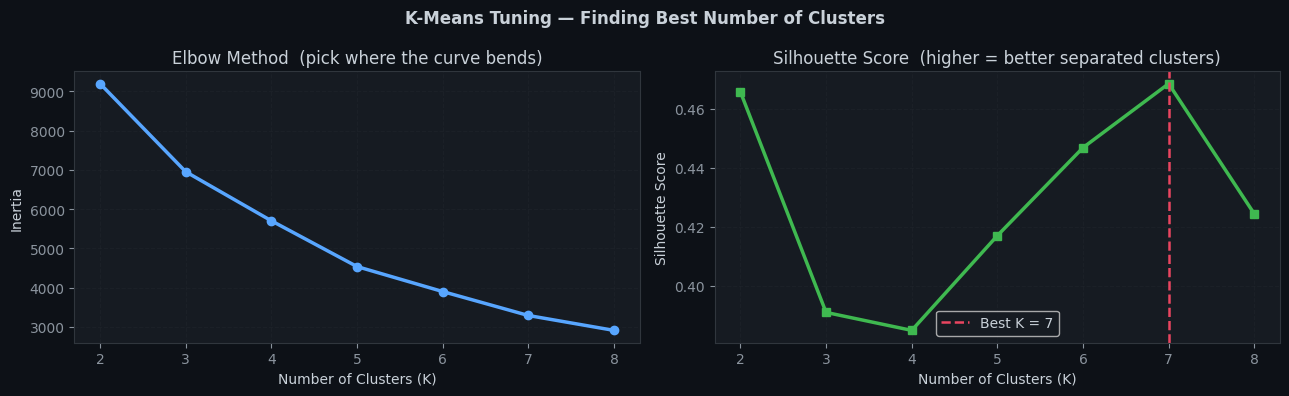

Best K = 7  (Silhouette Score = 0.4685)


In [105]:
# ── Tune K-Means — find best number of clusters ──────────────────────────────
k_values   = range(2, 9)
inertias   = []
sil_scores = []

for k in k_values:
    km  = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    lbl = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(
        silhouette_score(X, lbl, sample_size=min(2000, len(X)), random_state=SEED)
    )

best_k = list(k_values)[sil_scores.index(max(sil_scores))]

# Plot elbow and silhouette side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('K-Means Tuning — Finding Best Number of Clusters',
             fontsize=12, fontweight='bold')

# Elbow
axes[0].plot(list(k_values), inertias, color=PRIMARY, marker='o', linewidth=2.5)
axes[0].set_title('Elbow Method  (pick where the curve bends)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True)

# Silhouette
axes[1].plot(list(k_values), sil_scores, color=BASELINE, marker='s', linewidth=2.5)
axes[1].axvline(best_k, color=ANOMALY, linestyle='--', linewidth=1.8,
                label=f'Best K = {best_k}')
axes[1].set_title('Silhouette Score  (higher = better separated clusters)')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend(fontsize=10)
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f'Best K = {best_k}  (Silhouette Score = {max(sil_scores):.4f})')

In [106]:
# ── Fit K-Means with best K ───────────────────────────────────────────────────
km_model  = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
km_labels = km_model.fit_predict(X)
user_df['km_cluster'] = km_labels

# ── Cluster profiles — what does each cluster represent? ─────────────────────
PROFILE_COLS = ['heart_rate', 'steps', 'activity_level', 'is_asleep', 'hour']
profile = (
    user_df.groupby('km_cluster')[PROFILE_COLS]
    .mean()
    .round(2)
)
profile.columns = ['Avg HR', 'Avg Steps', 'Activity', 'Asleep Frac', 'Avg Hour']

# Auto-label each cluster with a simple description
def describe_cluster(row):
    if row['Asleep Frac'] > 0.7:
        return 'Sleep'
    elif row['Avg Steps'] > 30:
        return 'Active'
    elif row['Avg HR'] > profile['Avg HR'].mean():
        return 'Elevated HR'
    else:
        return 'Rest'

profile['Description'] = profile.apply(describe_cluster, axis=1)

print(f'K-Means Cluster Profiles (K={best_k}):')
print(profile.to_string())

K-Means Cluster Profiles (K=7):
            Avg HR  Avg Steps  Activity  Asleep Frac  Avg Hour Description
km_cluster                                                                
0            78.37      44.46      0.99         0.00     15.56      Active
1            56.29       0.01      0.00         1.00      3.30       Sleep
2            64.06      17.59      0.73         0.00      3.58        Rest
3            64.62       7.34      0.19         0.26     21.80        Rest
4            82.01      97.30      2.00         0.00     14.12      Active
5            84.14      51.90      1.00         0.00      9.49      Active
6            80.00      69.56      1.35         0.00      8.14      Active


---
## 10 · Visualizations

Now we bring together the results from all three models.
Each chart answers a specific question about this person's health behavior.

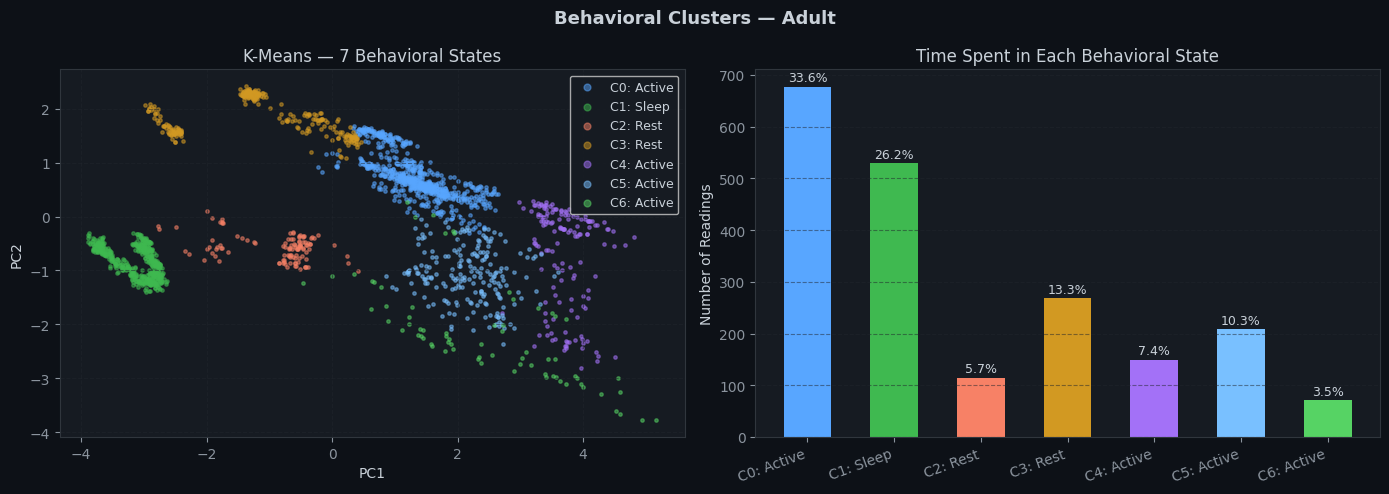

In [107]:
# ── Plot 1: K-Means clusters in PCA space ────────────────────────────────────
CLUSTER_COLORS = ['#58a6ff', '#3fb950', '#f78166', '#d29922',
                  '#a371f7', '#79c0ff', '#56d364', '#ffa657']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Behavioral Clusters — {USER_ID.replace("_001","").capitalize()}',
             fontsize=13, fontweight='bold')

# K-Means clusters in PCA space
ax = axes[0]
for k in range(best_k):
    mask  = km_labels == k
    desc  = profile.loc[k, 'Description']
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=CLUSTER_COLORS[k], s=6, alpha=0.5,
               label=f'C{k}: {desc}')
ax.set_title(f'K-Means — {best_k} Behavioral States')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(fontsize=9, markerscale=2)
ax.grid(True)

# Time in each cluster (bar chart)
ax = axes[1]
cluster_counts = user_df['km_cluster'].value_counts().sort_index()
cluster_labels = [f'C{i}: {profile.loc[i,"Description"]}' for i in cluster_counts.index]
bars = ax.bar(cluster_labels, cluster_counts.values,
              color=[CLUSTER_COLORS[i] for i in cluster_counts.index],
              edgecolor='none', width=0.55)
for bar, val in zip(bars, cluster_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            f'{val/len(user_df)*100:.1f}%',
            ha='center', va='bottom', fontsize=9)
ax.set_title('Time Spent in Each Behavioral State')
ax.set_ylabel('Number of Readings')
ax.set_xticklabels(cluster_labels, rotation=20, ha='right')
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

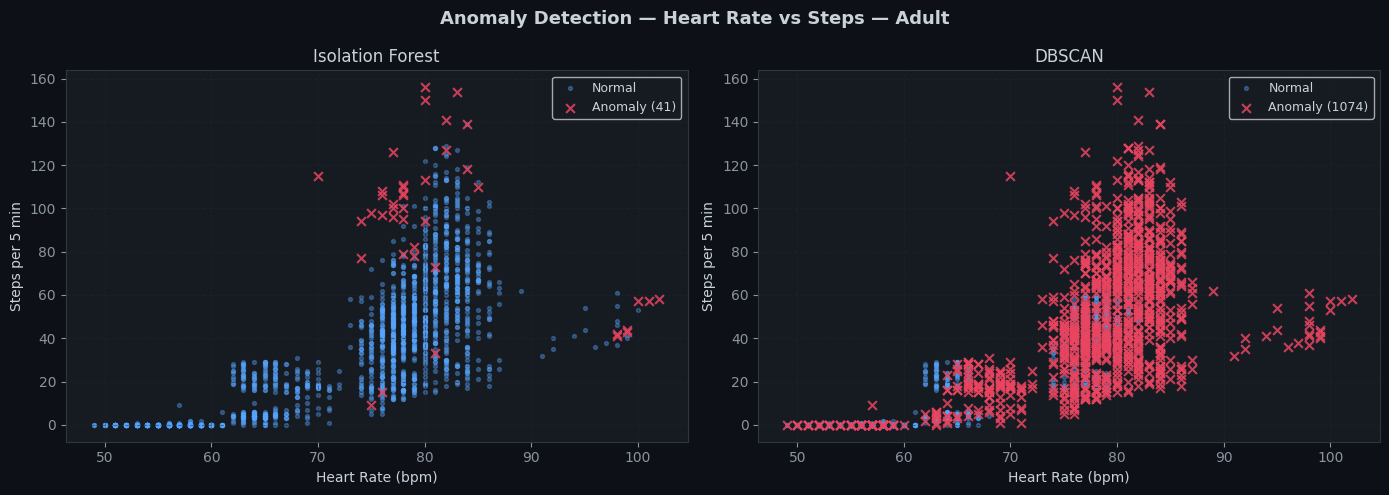

In [108]:
# ── Plot 2: Anomaly scatter — heart rate vs steps ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Anomaly Detection — Heart Rate vs Steps — '
             f'{USER_ID.replace("_001","").capitalize()}',
             fontsize=13, fontweight='bold')

for ax, (col, title) in zip(axes, [
    ('if_anomaly', 'Isolation Forest'),
    ('db_anomaly', 'DBSCAN'),
]):
    normal  = user_df[user_df[col] == 0]
    flagged = user_df[user_df[col] == 1]

    ax.scatter(normal['heart_rate'],  normal['steps'],
               c=PRIMARY, s=8, alpha=0.35, label='Normal')

    if len(flagged) > 0:
        ax.scatter(flagged['heart_rate'], flagged['steps'],
                   c=ANOMALY, s=40, alpha=0.85, zorder=5,
                   label=f'Anomaly ({len(flagged)})', marker='x', linewidths=1.5)

    ax.set_title(title)
    ax.set_xlabel('Heart Rate (bpm)')
    ax.set_ylabel('Steps per 5 min')
    ax.legend(fontsize=9)
    ax.grid(True)

plt.tight_layout()
plt.show()

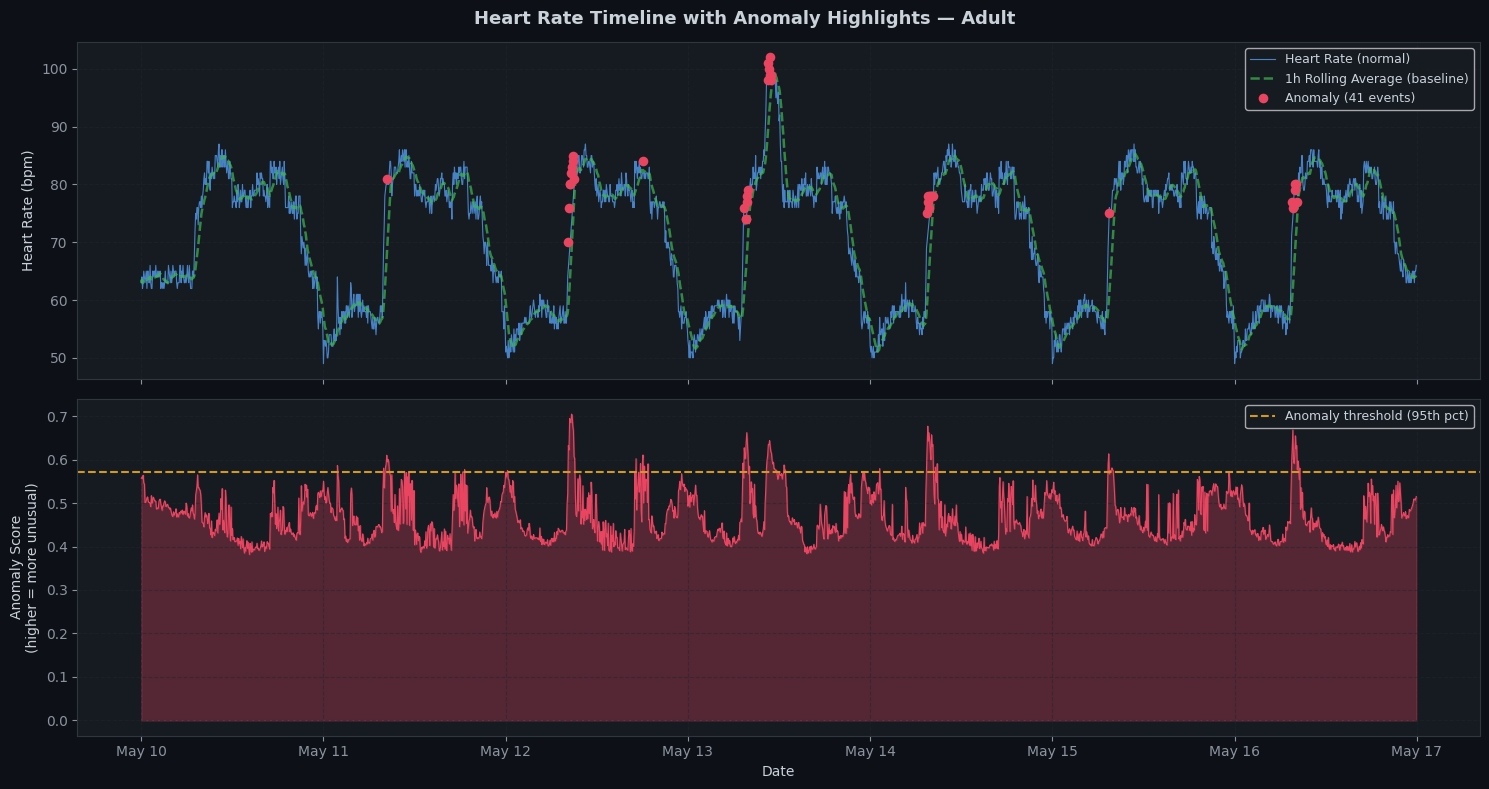

In [109]:
# ── Plot 3: Isolation Forest anomalies on the heart rate timeline ─────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
fig.suptitle(f'Heart Rate Timeline with Anomaly Highlights — '
             f'{USER_ID.replace("_001","").capitalize()}',
             fontsize=13, fontweight='bold')

# Top: heart rate + baseline
ax = axes[0]
normal  = user_df[user_df['if_anomaly'] == 0]
flagged = user_df[user_df['if_anomaly'] == 1]

ax.plot(normal['timestamp'], normal['heart_rate'],
        color=PRIMARY, linewidth=0.8, alpha=0.75, label='Heart Rate (normal)')
ax.plot(user_df['timestamp'], user_df['hr_rolling_avg'],
        color=BASELINE, linewidth=1.8, linestyle='--',
        alpha=0.7, label='1h Rolling Average (baseline)')

if len(flagged) > 0:
    ax.scatter(flagged['timestamp'], flagged['heart_rate'],
               color=ANOMALY, s=35, zorder=5,
               label=f'Anomaly ({len(flagged)} events)')

ax.set_ylabel('Heart Rate (bpm)')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True)

# Bottom: anomaly score
ax = axes[1]
ax.fill_between(user_df['timestamp'], user_df['if_score'],
                alpha=0.3, color=ANOMALY)
ax.plot(user_df['timestamp'], user_df['if_score'],
        color=ANOMALY, linewidth=0.8)
threshold_line = np.percentile(user_df['if_score'], 95)
ax.axhline(threshold_line, color=SECONDARY, linestyle='--',
           linewidth=1.5, label='Anomaly threshold (95th pct)')
ax.set_ylabel('Anomaly Score\n(higher = more unusual)')
ax.set_xlabel('Date')
ax.legend(fontsize=9)
ax.grid(True)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator())

plt.tight_layout()
plt.show()

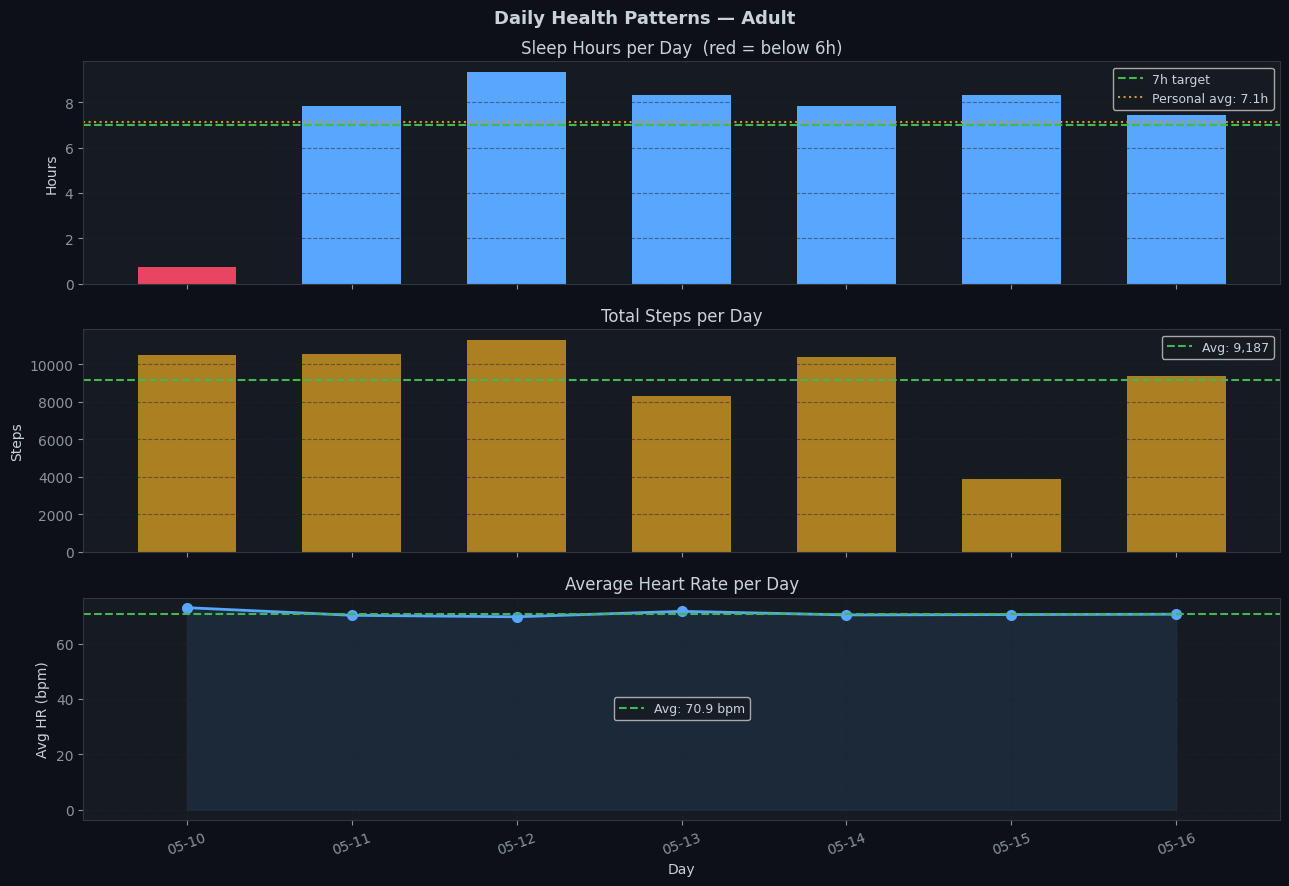

In [110]:
# ── Plot 4: Daily sleep pattern ───────────────────────────────────────────────
user_df['date'] = user_df['timestamp'].dt.date

daily_sleep = (
    user_df[user_df['sleep_state'] == 'asleep']
    .groupby('date')
    .size()
    * 5 / 60   # convert 5-min intervals to hours
)
daily_steps = user_df.groupby('date')['steps'].sum()
daily_hr    = user_df.groupby('date')['heart_rate'].mean()

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
fig.suptitle(f'Daily Health Patterns — {USER_ID.replace("_001","").capitalize()}',
             fontsize=13, fontweight='bold')

# Sleep hours per day
ax = axes[0]
colors_sleep = [ANOMALY if h < 6 else PRIMARY for h in daily_sleep]
ax.bar(range(len(daily_sleep)), daily_sleep.values,
       color=colors_sleep, edgecolor='none', width=0.6)
ax.axhline(7, color=BASELINE, linestyle='--', linewidth=1.5, label='7h target')
ax.axhline(daily_sleep.mean(), color=SECONDARY, linestyle=':', linewidth=1.5,
           label=f'Personal avg: {daily_sleep.mean():.1f}h')
ax.set_title('Sleep Hours per Day  (red = below 6h)')
ax.set_ylabel('Hours')
ax.legend(fontsize=9)
ax.grid(True, axis='y')

# Daily steps
ax = axes[1]
ax.bar(range(len(daily_steps)), daily_steps.values,
       color=SECONDARY, edgecolor='none', width=0.6, alpha=0.8)
ax.axhline(daily_steps.mean(), color=BASELINE, linestyle='--', linewidth=1.5,
           label=f'Avg: {daily_steps.mean():,.0f}')
ax.set_title('Total Steps per Day')
ax.set_ylabel('Steps')
ax.legend(fontsize=9)
ax.grid(True, axis='y')

# Average heart rate per day
ax = axes[2]
ax.plot(range(len(daily_hr)), daily_hr.values,
        color=PRIMARY, marker='o', linewidth=2, markersize=7)
ax.fill_between(range(len(daily_hr)), daily_hr.values,
                alpha=0.1, color=PRIMARY)
ax.axhline(daily_hr.mean(), color=BASELINE, linestyle='--', linewidth=1.5,
           label=f'Avg: {daily_hr.mean():.1f} bpm')
ax.set_title('Average Heart Rate per Day')
ax.set_ylabel('Avg HR (bpm)')
ax.set_xlabel('Day')
ax.set_xticks(range(len(daily_hr)))
ax.set_xticklabels([str(d)[5:] for d in daily_hr.index], rotation=20)
ax.legend(fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.show()

---
## 11 · Health Insights & Anomaly Severity

We combine all model results into a single **anomaly severity score**
and generate personalized health insights.

### Scoring logic
```
Severity Score = (IF score, normalized)
              + (agreement: flagged by multiple models)
```

A reading is **high severity** if:
- It has a high Isolation Forest score, **AND**
- It was also flagged by DBSCAN or appears in a small K-Means cluster

In [111]:
# ── Compute anomaly severity score ────────────────────────────────────────────
def normalize(series):
    """Scale any series to the range [0, 1]."""
    lo, hi = series.min(), series.max()
    if hi == lo:
        return series * 0
    return (series - lo) / (hi - lo)


# Normalized Isolation Forest score (0 to 1)
if_norm = normalize(user_df['if_score'])

# DBSCAN agreement bonus (+0.3 if also flagged by DBSCAN)
db_bonus = user_df['db_anomaly'] * 0.3

# Compute final severity: IF score is the primary signal
user_df['severity_score'] = (if_norm * 0.7 + db_bonus * 0.3).clip(0, 1)

# Categorize severity level
def label_severity(score):
    if score >= 0.75:
        return 'Critical'
    elif score >= 0.55:
        return 'High'
    elif score >= 0.35:
        return 'Medium'
    elif score >= 0.15:
        return 'Low'
    else:
        return 'Normal'

user_df['severity_level'] = user_df['severity_score'].apply(label_severity)

# Summary
severity_counts = user_df['severity_level'].value_counts()
print('Severity Level Distribution:')
for level in ['Critical', 'High', 'Medium', 'Low', 'Normal']:
    count = severity_counts.get(level, 0)
    bar   = '█' * (count // 10)
    print(f'  {level:8s}: {count:4d}  {bar}')

Severity Level Distribution:
  Critical:    4  
  High    :   49  ████
  Medium  :  348  ██████████████████████████████████
  Low     :  950  ███████████████████████████████████████████████████████████████████████████████████████████████
  Normal  :  665  ██████████████████████████████████████████████████████████████████


In [112]:
# ── Personalized health baseline ──────────────────────────────────────────────
baseline = {
    'avg_heart_rate'   : user_df['heart_rate'].mean(),
    'std_heart_rate'   : user_df['heart_rate'].std(),
    'max_heart_rate'   : user_df['heart_rate'].max(),
    'avg_daily_steps'  : daily_steps.mean(),
    'avg_sleep_hours'  : daily_sleep.mean(),
    'sleep_consistency': daily_sleep.std(),   # lower = more consistent
    'anomaly_rate'     : user_df['if_anomaly'].mean() * 100,
}

# Stability index: lower anomaly rate and consistent sleep = more stable
stability = max(0, 1 - baseline['anomaly_rate']/100 - baseline['sleep_consistency']/10)
stability = round(min(stability, 1.0), 3)

print(f'PERSONALIZED HEALTH BASELINE — {USER_ID.replace("_001","").upper()}')
print('═' * 52)
print(f'  Avg Heart Rate     : {baseline["avg_heart_rate"]:.1f} bpm')
print(f'  HR Std Dev         : {baseline["std_heart_rate"]:.1f} bpm  '
      f'({"stable" if baseline["std_heart_rate"] < 10 else "variable"})')
print(f'  Max Heart Rate     : {baseline["max_heart_rate"]:.0f} bpm')
print(f'  Avg Daily Steps    : {baseline["avg_daily_steps"]:,.0f}')
print(f'  Avg Sleep          : {baseline["avg_sleep_hours"]:.1f} hours/day')
print(f'  Sleep Consistency  : {baseline["sleep_consistency"]:.2f} '
      f'({"consistent" if baseline["sleep_consistency"] < 1.5 else "irregular"})')
print(f'  Anomaly Rate       : {baseline["anomaly_rate"]:.1f}%')
print(f'  Stability Index    : {stability:.3f}  (1.0 = perfectly stable)')
print('═' * 52)

PERSONALIZED HEALTH BASELINE — ADULT
════════════════════════════════════════════════════
  Avg Heart Rate     : 70.9 bpm
  HR Std Dev         : 11.2 bpm  (variable)
  Max Heart Rate     : 102 bpm
  Avg Daily Steps    : 9,187
  Avg Sleep          : 7.1 hours/day
  Sleep Consistency  : 2.87 (irregular)
  Anomaly Rate       : 2.0%
  Stability Index    : 0.692  (1.0 = perfectly stable)
════════════════════════════════════════════════════


In [113]:
# ── Generate personalized health insights ─────────────────────────────────────
print(f'PERSONALIZED HEALTH INSIGHTS — {USER_ID.replace("_001","").upper()}')
print('═' * 55)

insights = []

# 1. Heart rate spikes
hr_mean = user_df['heart_rate'].mean()
hr_std  = user_df['heart_rate'].std()
hr_high = user_df[user_df['heart_rate'] > hr_mean + 2 * hr_std]
if len(hr_high) > 0:
    insight = (f'⚠  {len(hr_high)} readings show elevated HR '
               f'(> {hr_mean + 2*hr_std:.0f} bpm, 2σ above personal avg).')
    insights.append(insight)
    print(f'\n{insight}')

# 2. Low sleep days
low_sleep_days = daily_sleep[daily_sleep < 6]
if len(low_sleep_days) > 0:
    insight = (f'⚠  {len(low_sleep_days)} day(s) with < 6 hours of sleep detected: '
               f'{[str(d)[5:] for d in low_sleep_days.index]}')
    insights.append(insight)
    print(f'\n{insight}')

# 3. Activity drop
if daily_steps.min() < daily_steps.mean() * 0.4:
    low_day = daily_steps.idxmin()
    insight = (f'⚠  Sudden activity drop on {str(low_day)[5:]}: '
               f'{daily_steps.min():,.0f} steps '
               f'(avg is {daily_steps.mean():,.0f}).')
    insights.append(insight)
    print(f'\n{insight}')

# 4. Anomaly bursts — days with many anomalies
user_df['date_str'] = user_df['date'].astype(str)
anomaly_by_day = user_df.groupby('date_str')['if_anomaly'].sum()
high_anom_days = anomaly_by_day[anomaly_by_day > anomaly_by_day.mean() + anomaly_by_day.std()]
if len(high_anom_days) > 0:
    insight = (f'⚠  High anomaly days: {high_anom_days.index.tolist()} '
               f'({high_anom_days.max()} anomalies on worst day).')
    insights.append(insight)
    print(f'\n{insight}')

# 5. Positive finding
if baseline['anomaly_rate'] < 4.0:
    insight = f'✓  Overall anomaly rate is low ({baseline["anomaly_rate"]:.1f}%) — good health stability.'
    insights.append(insight)
    print(f'\n{insight}')

if len(insights) == 0:
    print('\n✓  No significant health anomalies detected.')

print()

PERSONALIZED HEALTH INSIGHTS — ADULT
═══════════════════════════════════════════════════════

⚠  20 readings show elevated HR (> 93 bpm, 2σ above personal avg).

⚠  1 day(s) with < 6 hours of sleep detected: ['05-10']

⚠  High anomaly days: ['2026-05-13'] (13 anomalies on worst day).

✓  Overall anomaly rate is low (2.0%) — good health stability.



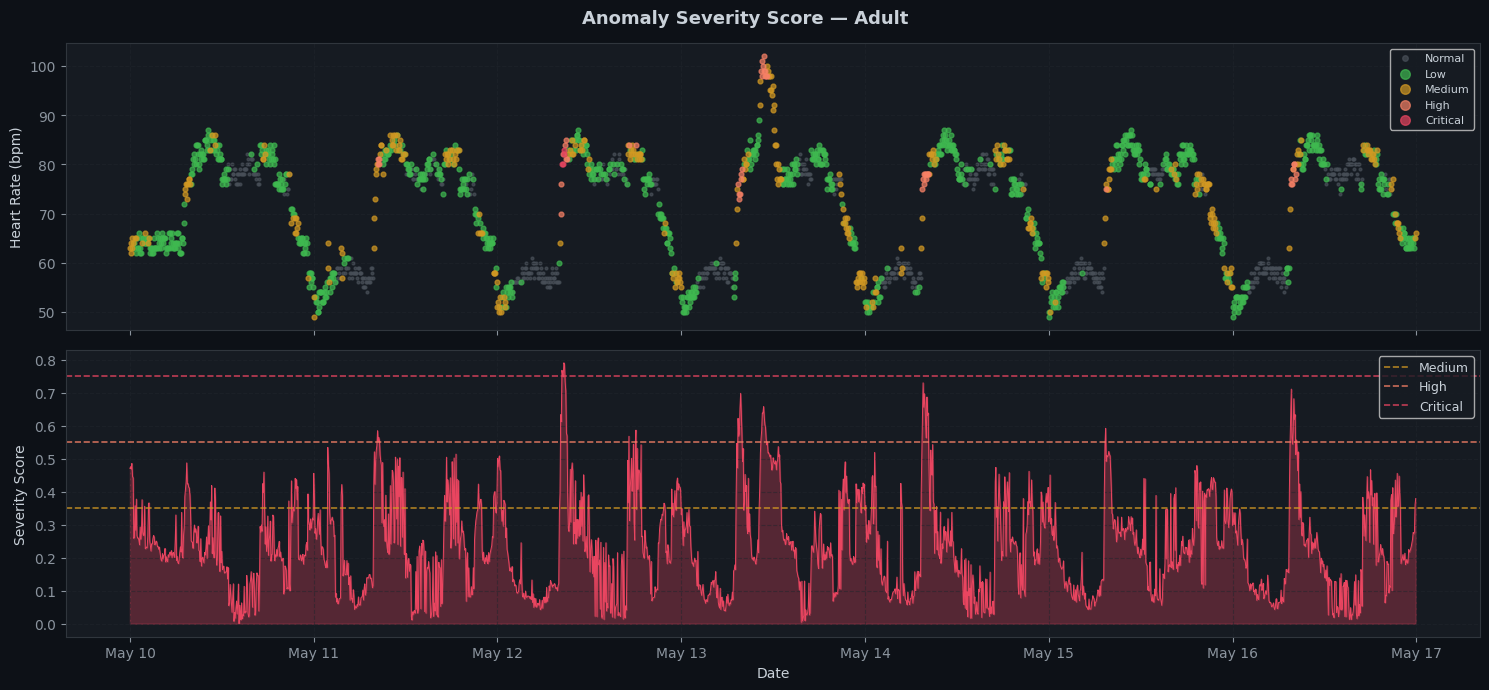

In [114]:
# ── Severity score plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
fig.suptitle(f'Anomaly Severity Score — {USER_ID.replace("_001","").capitalize()}',
             fontsize=13, fontweight='bold')

SEVERITY_COLORS = {
    'Normal': '#484f58', 'Low': BASELINE,
    'Medium': SECONDARY, 'High': '#f78166', 'Critical': ANOMALY,
}

# Top: heart rate coloured by severity
ax = axes[0]
for level, color in SEVERITY_COLORS.items():
    mask = user_df['severity_level'] == level
    if mask.any():
        size   = 4 if level == 'Normal' else 12
        zorder = 1 if level == 'Normal' else 5
        ax.scatter(user_df.loc[mask, 'timestamp'],
                   user_df.loc[mask, 'heart_rate'],
                   c=color, s=size, alpha=0.7,
                   label=level, zorder=zorder)

ax.set_ylabel('Heart Rate (bpm)')
ax.legend(fontsize=8, loc='upper right', markerscale=2)
ax.grid(True)

# Bottom: severity score over time
ax = axes[1]
ax.fill_between(user_df['timestamp'], user_df['severity_score'],
                alpha=0.3, color=ANOMALY)
ax.plot(user_df['timestamp'], user_df['severity_score'],
        color=ANOMALY, linewidth=0.7)
for level, thresh in [('Medium', 0.35), ('High', 0.55), ('Critical', 0.75)]:
    ax.axhline(thresh, color=SEVERITY_COLORS[level],
               linestyle='--', linewidth=1.2, alpha=0.8, label=level)
ax.set_ylabel('Severity Score')
ax.set_xlabel('Date')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator())

plt.tight_layout()
plt.show()

---
## 12 · Model Comparison & Best Model Selection

In [115]:
# ── Build model comparison table ─────────────────────────────────────────────
comparison = [
    {
        'Model'            : 'Isolation Forest',
        'Type'             : 'Anomaly Detection',
        'Best Parameters'  : f'contamination={best_cont}, n_estimators={best_n_est}',
        'Anomalies Found'  : user_df['if_anomaly'].sum(),
        'Anomaly Rate'     : f'{user_df["if_anomaly"].mean()*100:.1f}%',
        'Tuning Metric'    : 'Silhouette Score',
        'Strengths'        : 'Fast, no shape assumption, works well on most data',
        'Limitations'      : 'Contamination must be set manually',
    },
    {
        'Model'            : 'DBSCAN',
        'Type'             : 'Density Clustering',
        'Best Parameters'  : f'eps={best_eps}, min_samples={best_ms}',
        'Anomalies Found'  : user_df['db_anomaly'].sum(),
        'Anomaly Rate'     : f'{user_df["db_anomaly"].mean()*100:.1f}%',
        'Tuning Metric'    : 'Silhouette Score',
        'Strengths'        : 'No assumed cluster shape, direct noise labeling',
        'Limitations'      : 'Sensitive to eps and min_samples choice',
    },
    {
        'Model'            : 'K-Means',
        'Type'             : 'Behavioral Clustering',
        'Best Parameters'  : f'n_clusters={best_k}',
        'Anomalies Found'  : f'N/A (smallest cluster ≈ outliers)',
        'Anomaly Rate'     : 'N/A',
        'Tuning Metric'    : 'Silhouette Score',
        'Strengths'        : 'Reveals behavioral states / lifestyle patterns',
        'Limitations'      : 'No direct anomaly label; assumes spherical clusters',
    },
]

cmp_df = pd.DataFrame(comparison).set_index('Model')

print('MODEL COMPARISON')
print('═' * 90)
for model, row in cmp_df.iterrows():
    print(f'\n  {model}  ({row["Type"]})')
    print(f'    Parameters   : {row["Best Parameters"]}')
    print(f'    Anomalies    : {row["Anomalies Found"]} ({row["Anomaly Rate"]})')
    print(f'    Strengths    : {row["Strengths"]}')
    print(f'    Limitations  : {row["Limitations"]}')
print()

MODEL COMPARISON
══════════════════════════════════════════════════════════════════════════════════════════

  Isolation Forest  (Anomaly Detection)
    Parameters   : contamination=0.02, n_estimators=50
    Anomalies    : 41 (2.0%)
    Strengths    : Fast, no shape assumption, works well on most data
    Limitations  : Contamination must be set manually

  DBSCAN  (Density Clustering)
    Parameters   : eps=0.3, min_samples=20
    Anomalies    : 1074 (53.3%)
    Strengths    : No assumed cluster shape, direct noise labeling
    Limitations  : Sensitive to eps and min_samples choice

  K-Means  (Behavioral Clustering)
    Parameters   : n_clusters=7
    Anomalies    : N/A (smallest cluster ≈ outliers) (N/A)
    Strengths    : Reveals behavioral states / lifestyle patterns
    Limitations  : No direct anomaly label; assumes spherical clusters



In [116]:
# ── Best model recommendation ─────────────────────────────────────────────────
if_anom_n = user_df['if_anomaly'].sum()
db_anom_n = user_df['db_anomaly'].sum()

# Simple rule: best model is the one with cleaner separation (silhouette-guided)
# Isolation Forest has per-point scores which is more actionable
print('BEST MODEL RECOMMENDATION')
print('═' * 45)
print(f'  ★  Isolation Forest')
print(f'     → Best for this use case because:')
print(f'        • Gives a continuous anomaly score (not just yes/no)')
print("        • Tuned specifically to this person's data")
print(f'        • Fast and interpretable for a health monitoring demo')
print()
print(f'  DBSCAN is a good complement — use it to confirm high-severity flags.')
print(f'  K-Means is best for storytelling: "this person has {best_k} behavioral states."')
print()

# Agreement analysis: how often do IF and DBSCAN agree?
both_flagged = ((user_df['if_anomaly'] == 1) & (user_df['db_anomaly'] == 1)).sum()
print(f'  Agreement: {both_flagged} readings flagged by BOTH Isolation Forest and DBSCAN')
print(f'  → These are the highest-confidence anomalies to investigate first.')

BEST MODEL RECOMMENDATION
═════════════════════════════════════════════
  ★  Isolation Forest
     → Best for this use case because:
        • Gives a continuous anomaly score (not just yes/no)
        • Tuned specifically to this person's data
        • Fast and interpretable for a health monitoring demo

  DBSCAN is a good complement — use it to confirm high-severity flags.
  K-Means is best for storytelling: "this person has 7 behavioral states."

  Agreement: 41 readings flagged by BOTH Isolation Forest and DBSCAN
  → These are the highest-confidence anomalies to investigate first.


In [117]:
# ── Top 15 most anomalous events ─────────────────────────────────────────────
event_log = (
    user_df[user_df['if_anomaly'] == 1][
        ['timestamp', 'heart_rate', 'steps', 'activity_level',
         'sleep_state', 'if_score', 'db_anomaly', 'severity_level']
    ]
    .sort_values('if_score', ascending=False)
    .reset_index(drop=True)
)

event_log['if_score']  = event_log['if_score'].round(4)
event_log['db_anomaly'] = event_log['db_anomaly'].map({1: '⚠ yes', 0: 'no'})

print(f'Top 15 Most Anomalous Events — {USER_ID.replace("_001","").capitalize()}')
print(event_log.head(15).to_string(index=True))

Top 15 Most Anomalous Events — Adult
             timestamp  heart_rate  steps  activity_level sleep_state  if_score db_anomaly severity_level
0  2026-05-12 08:40:00          83    154               2       awake    0.7046      ⚠ yes       Critical
1  2026-05-12 08:45:00          82    141               2       awake    0.7022      ⚠ yes       Critical
2  2026-05-12 08:25:00          80    156               2       awake    0.6942      ⚠ yes       Critical
3  2026-05-12 08:30:00          80    150               2       awake    0.6886      ⚠ yes       Critical
4  2026-05-12 08:35:00          82    127               2       awake    0.6853      ⚠ yes           High
5  2026-05-12 08:50:00          84    118               2       awake    0.6781      ⚠ yes           High
6  2026-05-14 07:35:00          77    126               2       awake    0.6767      ⚠ yes           High
7  2026-05-16 07:40:00          76    106               2       awake    0.6680      ⚠ yes           High
8  2026-0

---
## Final Summary

Raw wearable data → 9 behavioral features → 3 ML models → Personalized health insights